In [105]:
# 01 Data Import

# Goal: download and save the selected-pair equity dataset used by the rest of the pipeline.

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [107]:
import importlib
import pipeline_config as cfg

# Reload shared config so notebook picks up edits without a kernel restart.
cfg = importlib.reload(cfg)

BAR_INTERVAL = cfg.BAR_INTERVAL
DATA_PATH = cfg.DATA_PATH
END_DATE = cfg.END_DATE
PAIR_X = cfg.PAIR_X
PAIR_Y = cfg.PAIR_Y
SLEEVES = cfg.SLEEVES
START_DATE = cfg.START_DATE
UNIVERSE = cfg.UNIVERSE
ensure_project_dirs = cfg.ensure_project_dirs


In [108]:
ensure_project_dirs()

data_path = DATA_PATH


In [109]:
rows = []
for sleeve, tickers in SLEEVES.items():
    for ticker in tickers:
        rows.append([ticker, sleeve])

universe = pd.DataFrame(rows, columns=["ticker", "sleeve"])
universe = universe.sort_values(["sleeve", "ticker"]).reset_index(drop=True)

universe


,ticker,sleeve
0,CVX,selected_pair
1,XOM,selected_pair


In [110]:
tickers = universe["ticker"].tolist()

assert {PAIR_Y, PAIR_X} == set(tickers)
assert set(tickers) == set(UNIVERSE)
assert len(tickers) == 2

tickers

['CVX', 'XOM']

In [111]:
raw = yf.download(
    tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    interval=BAR_INTERVAL,
)


c:\Users\aryam\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\utils.py:636: Pandas4Warning: 'd' is deprecated and will be removed in a future version. Please use 'D' instead of 'd'.
  last_rows_same_interval = (dt2 - dt1) < _pd.Timedelta(interval)
c:\Users\aryam\AppData\Local\Programs\Python\Python313\Lib\site-packages\yfinance\utils.py:636: Pandas4Warning: 'd' is deprecated and will be removed in a future version. Please use 'D' instead of 'd'.
  last_rows_same_interval = (dt2 - dt1) < _pd.Timedelta(interval)
[*********************100%***********************]  2 of 2 completed


In [112]:
prices = raw["Close"].copy()

if isinstance(prices, pd.Series):
    prices = prices.to_frame()


In [113]:
prices = prices.sort_index()
prices = prices[prices.index.dayofweek < 5]
prices = prices.ffill().dropna()
prices.index.name = "Datetime"

assert prices.index.is_monotonic_increasing
assert prices.index.is_unique
assert set(prices.columns) == set(tickers)


In [114]:
log_prices = np.log(prices)
log_returns = log_prices.diff().dropna()

log_prices.index.name = "Datetime"
log_returns.index.name = "Datetime"


In [115]:
pd.Series(
    {
        "rows": len(prices),
        "cols": prices.shape[1],
        "first_timestamp": prices.index.min(),
        "last_timestamp": prices.index.max(),
    }
)


rows                                39
cols                                 2
first_timestamp    2025-06-26 00:00:00
last_timestamp     2026-03-23 00:00:00
dtype: object

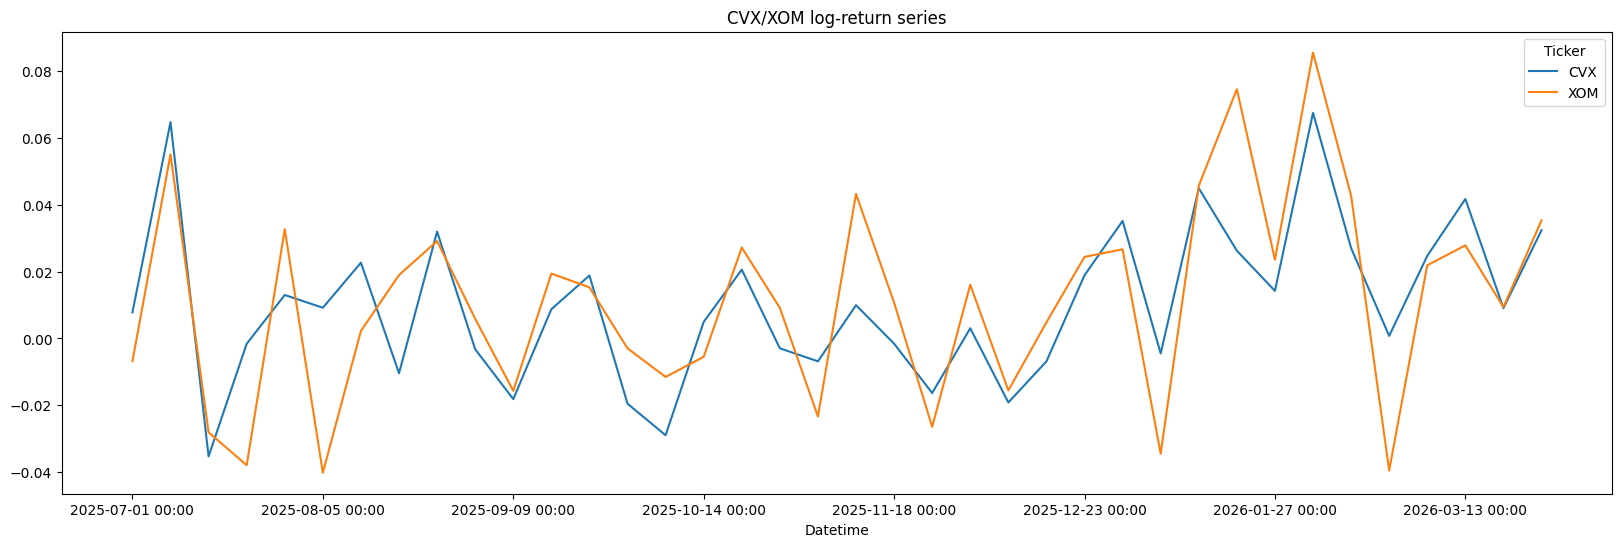

In [116]:
plot_example = log_returns[[PAIR_Y, PAIR_X]].copy()
plot_example.index = plot_example.index.strftime("%Y-%m-%d %H:%M")
plot_example.plot(title=f"{PAIR_Y}/{PAIR_X} log-return series", figsize=(20, 6))
plt.show()

In [117]:
universe.to_csv(data_path / "universe_metadata.csv", index=False)
prices.to_csv(data_path / "equity_prices.csv", index_label="Datetime")
log_prices.to_csv(data_path / "equity_log_prices.csv", index_label="Datetime")
log_returns.to_csv(data_path / "equity_returns.csv", index_label="Datetime")